# MeloWave - Mission 2 : prévoir l'activité d'un genre


## 1. Paramètres

Tout le notebook tourne autour de ces quatre valeurs. Pour analyser le hip hop sur le marché
français, il n'y a que la première ligne à changer.

In [1]:
# les quatre reglages du notebook : je peux changer de genre ou de marche ici
GENRE = "pop"
MARCHE = "Global"
JOURS_TEST = 90        # les 90 derniers jours servent a verifier le modele
JOURS_PREVISION = 180  # 6 mois de prevision finale

# les outils
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Prophet ecrit une ligne de journal a chaque entrainement : je le fais taire
logging.getLogger("cmdstanpy").disabled = True

# Prophet tire au sort pour estimer ses intervalles de confiance.
# sans cette graine, les bornes changent a chaque execution du notebook.
np.random.seed(42)

print(f"genre etudie : {GENRE}   marche : {MARCHE}")
print(f"test sur les {JOURS_TEST} derniers jours, prevision a {JOURS_PREVISION} jours")


genre etudie : pop   marche : Global
test sur les 90 derniers jours, prevision a 180 jours


Tout est déclaré ici. Si on me demande la même chose pour le hip hop ou
pour le marché français, je change deux mots dans cette cellule et je relance le notebook.


## 2. Chargement des données

In [2]:
# le fichier fait 1,4 Go : je ne charge que les 3 colonnes dont j'ai besoin
CHEMIN = "../data/chart_tracks_genre_2017_2020.csv"

charts = pd.read_csv(CHEMIN,
                     usecols=["country", "date", "genre"],
                     dtype={"country": "category", "genre": "category"})

print(f"{len(charts):,} lignes chargees")
print(f"memoire occupee : {charts.memory_usage(deep=True).sum() / 1e6:.0f} Mo")
print(f"{charts.country.nunique()} marches, {charts.genre.nunique()} genres")

9,807,001 lignes chargees
memoire occupee : 598 Mo
35 marches, 21 genres


Le fichier contient presque 10 millions de lignes. En ne gardant que le marché, la date et le genre,
il tient dans la mémoire de mon ordinateur.

Une ligne représente un morceau présent dans le Top 200 d'un marché, un jour donné.

In [3]:
# les dates sont ecrites jour/mois/annee : je dois le preciser
# sinon 05/11/2020 serait lu comme le 11 mai
marche = charts[charts.country == MARCHE].copy()
marche["date"] = pd.to_datetime(marche.date, dayfirst=True, errors="coerce")

print(f"{len(marche):,} lignes pour le marche {MARCHE}")
print(f"dates illisibles : {marche.date.isna().sum()}")
print(f"periode : du {marche.date.min():%d/%m/%Y} au {marche.date.max():%d/%m/%Y}")

280,200 lignes pour le marche Global
dates illisibles : 0
periode : du 01/01/2017 au 05/11/2020


Aucune date illisible, et la période va de début 2017 à fin 2020.

Le `dayfirst=True` n'est pas un détail. Sans lui, pandas lit les dates à l'américaine et confond le
jour et le mois pour toutes les dates où le jour est inférieur à 13. La série serait mélangée sans
aucun message d'erreur.


## 3. La série quotidienne

In [4]:
# je compte les morceaux du genre jour par jour, sur une grille de dates complete
grille = pd.date_range(marche.date.min(), marche.date.max(), freq="D")

serie_genre = marche[marche.genre == GENRE].groupby("date").size().reindex(grille, fill_value=0)
serie_totale = marche.groupby("date").size().reindex(grille, fill_value=0)

print(f"jours presents dans le fichier : {marche.date.nunique()}")
print(f"jours dans la grille complete  : {len(grille)}")
print(f"jours manquants                : {len(grille) - marche.date.nunique()}")

jours presents dans le fichier : 1401
jours dans la grille complete  : 1405
jours manquants                : 4


Quatre jours manquent dans le fichier. La grille complète les remet en place avec la valeur 0.

C'est indispensable. Sans grille, un jour absent disparaît sans bruit et le modèle croit que la
veille est directement suivie du surlendemain. Ses rythmes hebdomadaires seraient décalés.


### Vrai zéro ou trou de collecte ?

In [5]:
# un jour a zero peut vouloir dire deux choses tres differentes
jours_zero = serie_genre[serie_genre == 0]

print(f"{len(jours_zero)} jours a zero pour le genre {GENRE}\n")
print(f"{'date':12} {'lignes ce jour-la':>18} {'dont genre renseigne':>22}")
for date in jours_zero.index:
    lignes_du_jour = marche[marche.date == date]
    avec_genre = lignes_du_jour.genre.notna().sum()
    print(f"{date:%d/%m/%Y}   {len(lignes_du_jour):>16}   {avec_genre:>20}")

5 jours a zero pour le genre pop

date          lignes ce jour-la   dont genre renseigne
23/02/2017                  0                      0
30/05/2017                  0                      0
31/05/2017                  0                      0
02/06/2017                  0                      0
09/06/2018                200                      0


### Verdict

Quatre de ces jours ont **0 morceau au total** : le classement entier est absent, c'est un trou de
collecte. Aucun genre n'y figure, pas seulement la Pop.

Le cinquième, le 09/06/2018, est différent : le classement compte bien ses 200 morceaux, mais la
colonne du genre est vide pour les 200. C'est un défaut de la donnée, pas une journée sans Pop.

Dans les deux cas, ce ne sont pas de vrais zéros. Un vrai zéro voudrait dire « ce jour-là, aucun
morceau Pop n'était dans le Top 200 », ce qui n'est jamais arrivé.


In [6]:
# je remplace ces faux zeros par une valeur manquante : Prophet sait les ignorer
serie = serie_genre.astype(float)
serie[serie == 0] = np.nan

print(f"{serie.isna().sum()} jours passes en valeur manquante sur {len(serie)}")
print(f"soit {serie.isna().mean():.2%} de la serie")
print(f"\nla serie va de {serie.min():.0f} a {serie.max():.0f} morceaux par jour")

5 jours passes en valeur manquante sur 1405
soit 0.36% de la serie

la serie va de 51 a 114 morceaux par jour


Cinq jours sur 1 405, soit 0,36 % de la série. C'est négligeable, mais les laisser à zéro aurait
tiré la moyenne vers le bas et fait croire au modèle à des chutes brutales qui n'ont jamais eu lieu.

## 4. À quoi ressemble cette série ?

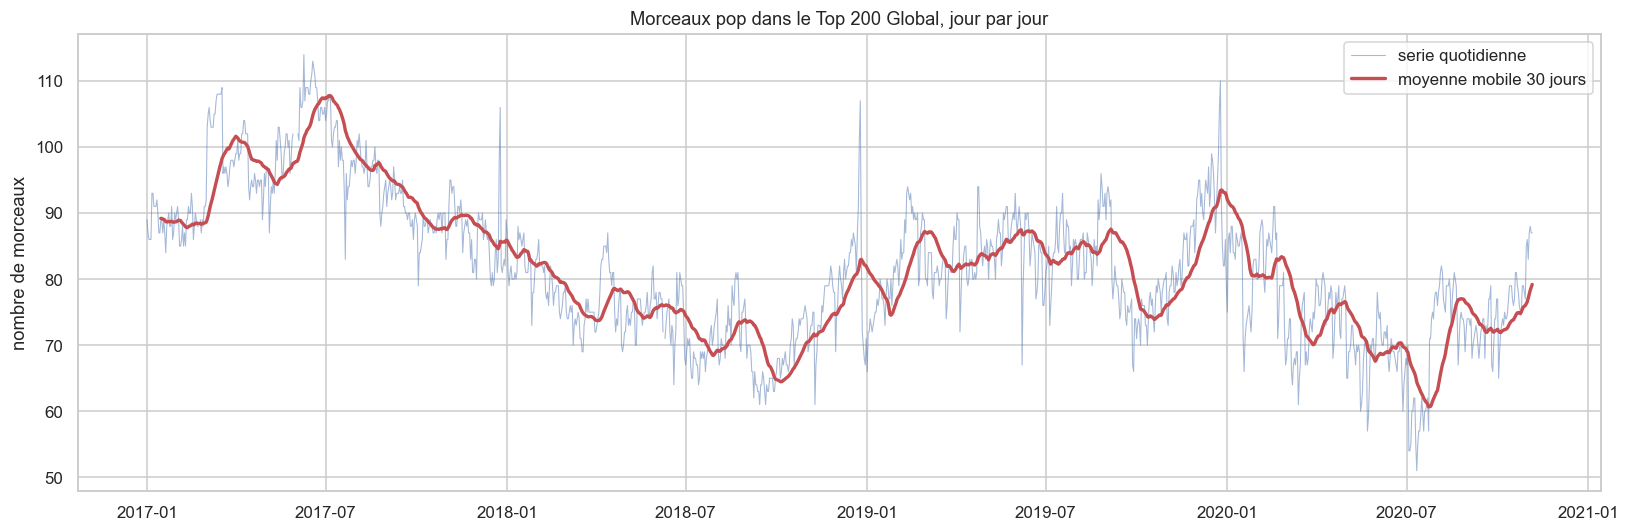

In [7]:
# la serie brute, et sa moyenne mobile 30 jours par-dessus
moyenne_mobile = serie.rolling(30, min_periods=15).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(serie.index, serie.values, lw=.7, alpha=.5, label="serie quotidienne")
ax.plot(moyenne_mobile.index, moyenne_mobile.values, lw=2.2, color="#C44E52",
        label="moyenne mobile 30 jours")
ax.set_title(f"Morceaux {GENRE} dans le Top 200 {MARCHE}, jour par jour")
ax.set_ylabel("nombre de morceaux")
ax.legend()
plt.tight_layout()
plt.show()

La courbe fine est le comptage quotidien, la courbe épaisse est la moyenne des 30 derniers jours.

Un mot sur cette moyenne mobile : je la calcule en regardant **vers l'arrière**, jamais vers l'avant.
Une moyenne centrée serait plus jolie, mais pour lisser le 15 mars elle utiliserait les valeurs du
20 mars. Dans un travail de prévision, se servir du futur pour expliquer le passé fausse tout. Je
m'interdis cette facilité dès le début, même sur un graphique de description.


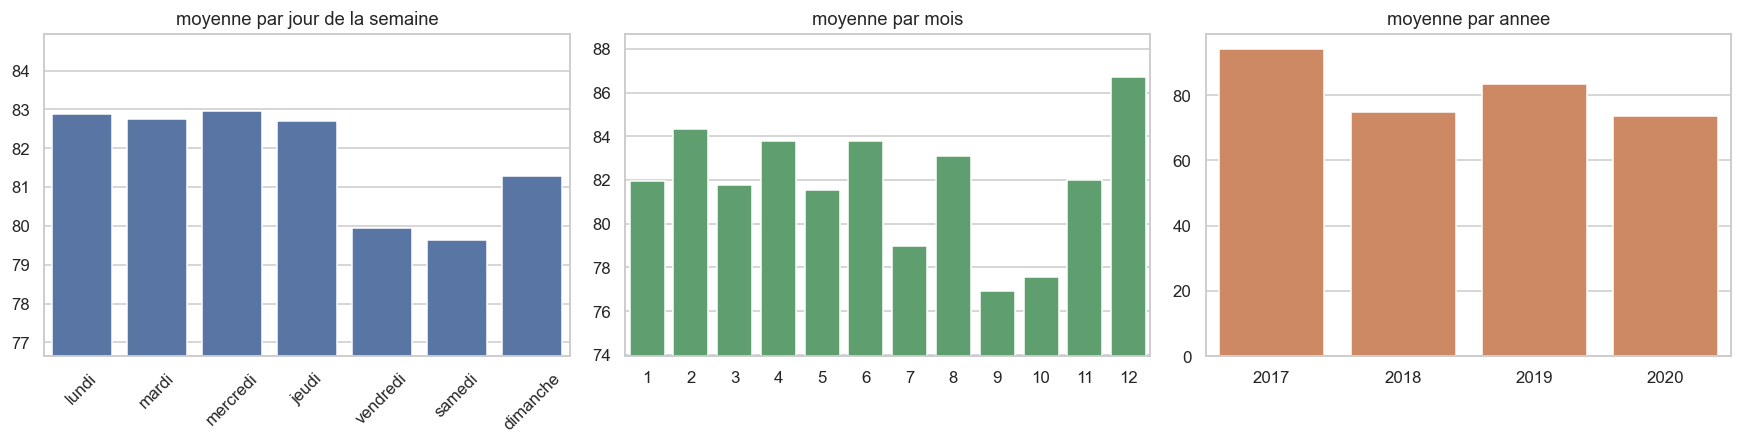

par jour de semaine :
  lundi      82.9
  mardi      82.7
  mercredi   83.0
  jeudi      82.7
  vendredi   79.9
  samedi     79.6
  dimanche   81.3

mois le plus haut : 12 (86.7)
mois le plus bas  : 9 (76.9)

par annee :
  2017 : 94.1
  2018 : 74.8
  2019 : 83.3
  2020 : 73.7


In [8]:
# les rythmes de la serie : par jour de semaine, par mois, par annee
jours_fr = ["lundi", "mardi", "mercredi", "jeudi", "vendredi", "samedi", "dimanche"]
connue = serie.dropna()

par_jour = connue.groupby(connue.index.dayofweek).mean()
par_mois = connue.groupby(connue.index.month).mean()
par_annee = connue.groupby(connue.index.year).mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sns.barplot(x=jours_fr, y=par_jour.values, ax=axes[0], color="#4C72B0")
axes[0].set_title("moyenne par jour de la semaine")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylim(par_jour.min() - 3, par_jour.max() + 2)

sns.barplot(x=par_mois.index, y=par_mois.values, ax=axes[1], color="#55A868")
axes[1].set_title("moyenne par mois")
axes[1].set_ylim(par_mois.min() - 3, par_mois.max() + 2)

sns.barplot(x=par_annee.index, y=par_annee.values, ax=axes[2], color="#DD8452")
axes[2].set_title("moyenne par annee")

for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

print("par jour de semaine :")
for i, nom in enumerate(jours_fr):
    print(f"  {nom:10} {par_jour[i]:.1f}")
print(f"\nmois le plus haut : {par_mois.idxmax()} ({par_mois.max():.1f})")
print(f"mois le plus bas  : {par_mois.idxmin()} ({par_mois.min():.1f})")

print("\npar annee :")
for annee, valeur in par_annee.items():
    print(f"  {annee} : {valeur:.1f}")


In [9]:
# le vendredi profite-t-il a la Pop ? je regarde un genre concurrent
hip = marche[marche.genre == "hip hop"].groupby("date").size().reindex(grille, fill_value=0)

part_hip = hip / serie_totale * 100
part_hip = part_hip[serie_totale > 0]   # j'ecarte les jours ou le classement est absent

semaine = part_hip[part_hip.index.dayofweek < 4].mean()
vendredi = part_hip[part_hip.index.dayofweek == 4].mean()
print(f"part du hip hop du lundi au jeudi : {semaine:.1f} %")
print(f"part du hip hop le vendredi       : {vendredi:.1f} %")

part du hip hop du lundi au jeudi : 12.3 %
part du hip hop le vendredi       : 13.8 %


### Ce que je lis dans la série

La Pop occupait 94,1 places sur 200 en moyenne en 2017, elle est à 73,7 en 2020. Elle reste le
premier genre du classement, mais elle perd du terrain.

Le rythme hebdomadaire va dans le sens inverse de l'intuition : le vendredi et le samedi sont les
deux points bas de la semaine, alors que le milieu de semaine tourne autour de 83.

Le vendredi est pourtant le jour de sortie des nouveautés. Mais elles arrivent dans tous les genres
à la fois et poussent dehors des titres Pop déjà installés. Le hip hop le montre : sa part monte de
12,3 % en semaine à 13,8 % le vendredi. Le pic de sorties existe bien, il profite juste aux autres.

Le rythme annuel est net, avec un creux en septembre et un pic en décembre. Les fêtes ramènent des
titres Pop dans le classement.


## 5. La prévision : d'abord la preuve, ensuite les chiffres

Camille demande une preuve avant les chiffres. Je mets donc de côté les 90 derniers jours et je n'y
touche plus, j'entraîne le modèle sur tout le reste, et je le confronte une seule fois à ces
90 jours qu'il n'a jamais vus.

Évaluer un modèle sur des jours qu'il a déjà vus n'a aucun sens : il les connaît par cœur. Le
découpage est donc chronologique, jamais tiré au hasard.

In [10]:
# decoupage : les 90 derniers jours sont mis de cote
donnees = serie.reset_index()
donnees.columns = ["ds", "y"]          # Prophet exige ces deux noms

train = donnees.iloc[:-JOURS_TEST]
test = donnees.iloc[-JOURS_TEST:]

print(f"entrainement : {len(train)} jours, du {train.ds.min():%d/%m/%Y} au {train.ds.max():%d/%m/%Y}")
print(f"test         : {len(test)} jours, du {test.ds.min():%d/%m/%Y} au {test.ds.max():%d/%m/%Y}")
print(f"\naucun jour en commun : {train.ds.max() < test.ds.min()}")

entrainement : 1315 jours, du 01/01/2017 au 07/08/2020
test         : 90 jours, du 08/08/2020 au 05/11/2020

aucun jour en commun : True


Le test commence le lendemain de la fin de l'entraînement. C'est le point sur lequel je ne peux pas
me tromper : si les deux périodes se chevauchaient, mon évaluation ne vaudrait rien.

### Un point de comparaison avant tout

Avant de lancer Prophet, je fixe un modèle naïf, c'est-à-dire la prévision la plus simple possible :
chaque jour ressemblera à la moyenne des sept derniers jours connus.

Ce modèle ne coûte rien et ne demande aucun calcul savant. Si Prophet ne fait pas mieux que lui, il
ne sert à rien.


In [11]:
# le modele naif : la moyenne des 7 derniers jours d'entrainement
reference = train.y.tail(7).mean()
reel = test.y.values

erreur_ref = np.nanmean(np.abs(reel - reference))
print(f"modele naif : je prevois {reference:.1f} morceaux tous les jours")
print(f"erreur moyenne de ce modele naif : {erreur_ref:.2f} morceaux par jour")

modele naif : je prevois 79.1 morceaux tous les jours
erreur moyenne de ce modele naif : 4.99 morceaux par jour


### Choisir le réglage sans fausser l'évaluation

Prophet a un réglage qui change tout : `changepoint_prior_scale`. Il dit au modèle à quel point la
tendance a le droit de changer de direction. Trop souple, il suit le moindre soubresaut. Trop
rigide, il trace une ligne droite et ignore les virages.

Je dois choisir une valeur, mais **pas en regardant les 90 jours de test**. Sinon je garderais celle
qui donne le meilleur score sur ces 90 jours, et mon évaluation ne mesurerait plus rien.

Je découpe donc une deuxième fois, à l'intérieur de l'entraînement : je réserve les 90 derniers
jours du train pour comparer les réglages entre eux.

In [12]:
# deuxieme decoupage, a l'interieur du train, pour choisir le reglage
train_court = train.iloc[:-JOURS_TEST]
validation = train.iloc[-JOURS_TEST:]

resultats = {}
for souplesse in [0.5, 0.1, 0.05, 0.01, 0.001]:
    essai = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                    daily_seasonality=False, changepoint_prior_scale=souplesse)
    essai.fit(train_court)
    p = essai.predict(essai.make_future_dataframe(periods=JOURS_TEST))
    prevu_val = p.set_index("ds").loc[validation.ds, "yhat"].values
    reel_val = validation.y.values
    connu = ~np.isnan(reel_val)
    resultats[souplesse] = np.mean(np.abs(reel_val[connu] - prevu_val[connu]))

for souplesse, erreur in resultats.items():
    print(f"changepoint_prior_scale = {souplesse:<6} erreur moyenne = {erreur:.2f}")

MEILLEUR = min(resultats, key=resultats.get)
print(f"\nje retiens {MEILLEUR}, et je n'y toucherai plus")

changepoint_prior_scale = 0.5    erreur moyenne = 9.05
changepoint_prior_scale = 0.1    erreur moyenne = 6.46
changepoint_prior_scale = 0.05   erreur moyenne = 7.30
changepoint_prior_scale = 0.01   erreur moyenne = 13.12
changepoint_prior_scale = 0.001  erreur moyenne = 9.89

je retiens 0.1, et je n'y toucherai plus


Le réglage retenu est celui qui se trompe le moins **sur la validation**, pas sur le test. À partir
d'ici, je le fige.

In [13]:
# le modele, avec le reglage choisi
modele = Prophet(
    yearly_seasonality=True,       # le rythme annuel existe : pic en decembre
    weekly_seasonality=True,       # le rythme hebdomadaire existe : creux le vendredi
    daily_seasonality=False,       # je n'ai qu'une valeur par jour, pas d'heures
    changepoint_prior_scale=MEILLEUR,
)
modele.fit(train)

prevision = modele.predict(modele.make_future_dataframe(periods=JOURS_TEST))
print(f"{len(prevision)} jours prevus, dont les {JOURS_TEST} du test")

1405 jours prevus, dont les 90 du test


J'active le rythme annuel parce que les moyennes par mois montrent un pic en décembre et un creux
en septembre. J'active le rythme hebdomadaire parce que les moyennes par jour montrent le creux du
vendredi et du samedi. Je désactive le rythme quotidien : je n'ai qu'une valeur par jour, il n'y a
pas d'heures à modéliser à l'intérieur d'une journée.

In [14]:
# les trois indicateurs d'erreur demandes
prevu = prevision.set_index("ds").loc[test.ds, "yhat"].values
connu = ~np.isnan(reel)

mae = np.mean(np.abs(reel[connu] - prevu[connu]))
rmse = np.sqrt(np.mean((reel[connu] - prevu[connu]) ** 2))
mape = np.mean(np.abs((reel[connu] - prevu[connu]) / reel[connu])) * 100
biais = np.mean(prevu[connu] - reel[connu])

print(f"MAE   : {mae:.2f} morceaux par jour")
print(f"RMSE  : {rmse:.2f}")
print(f"MAPE  : {mape:.1f} %")
print(f"biais : {biais:+.2f}  (negatif = le modele prevoit trop bas)")
print(f"\nle modele naif faisait {erreur_ref:.2f}")

MAE   : 16.92 morceaux par jour
RMSE  : 18.14
MAPE  : 22.2 %
biais : -16.92  (negatif = le modele prevoit trop bas)

le modele naif faisait 4.99


Le MAE est l'écart moyen, en morceaux par jour. C'est le plus parlant des trois parce qu'il est
dans la même unité que les données.

Le RMSE dit la même chose, mais les grosses erreurs y pèsent plus lourd. Quand il dépasse nettement
le MAE, c'est qu'il existe quelques journées très mal prévues.

Le MAPE donne l'erreur en pourcentage. Il devient instable quand les valeurs réelles approchent de
zéro, parce qu'on divise par un tout petit nombre. Ici la série tourne autour de 80, donc il reste
lisible.

Le biais, lui, garde le signe des écarts. Le MAE dit de combien on se trompe, le biais dit dans
quel sens.

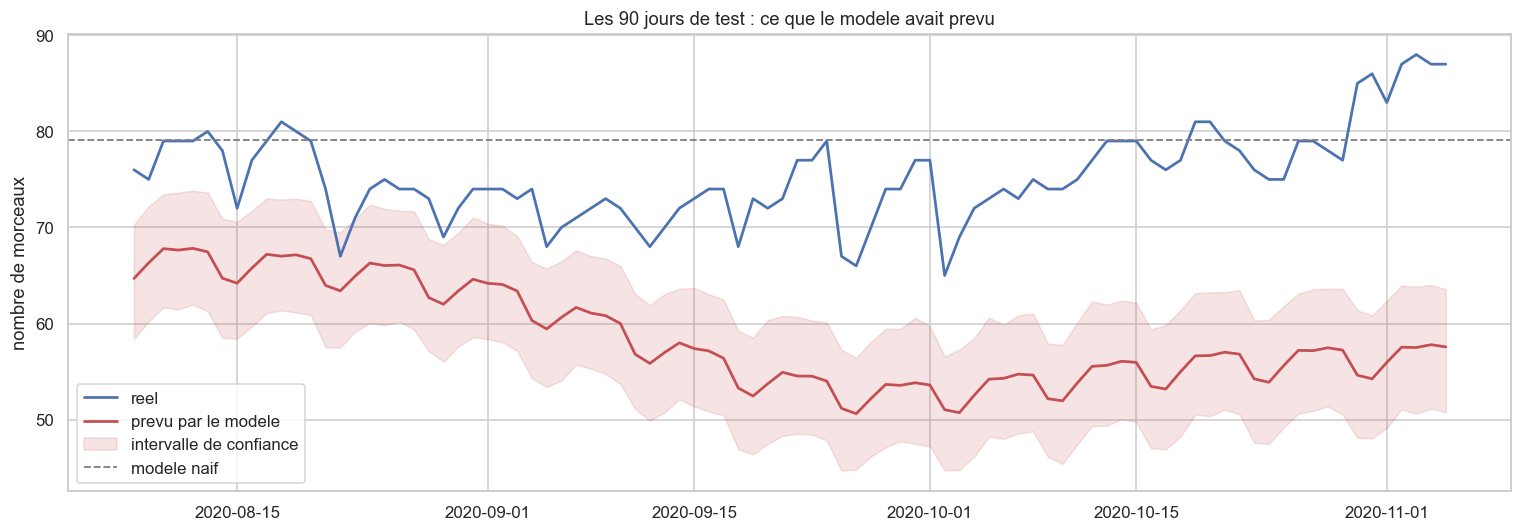

jours ou le reel tombe dans l'intervalle : 1 sur 90


In [15]:
# reel contre prevu sur les 90 jours mis de cote
prev_test = prevision.set_index("ds").loc[test.ds]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.ds, reel, lw=1.8, color="#4C72B0", label="reel")
ax.plot(test.ds, prev_test.yhat, lw=1.8, color="#C44E52", label="prevu par le modele")
ax.fill_between(test.ds, prev_test.yhat_lower, prev_test.yhat_upper,
                color="#C44E52", alpha=.15, label="intervalle de confiance")
ax.axhline(reference, ls="--", lw=1.2, color="grey", label="modele naif")
ax.set_title(f"Les {JOURS_TEST} jours de test : ce que le modele avait prevu")
ax.set_ylabel("nombre de morceaux")
ax.legend()
plt.tight_layout()
plt.show()

dedans = (reel >= prev_test.yhat_lower.values) & (reel <= prev_test.yhat_upper.values)
print(f"jours ou le reel tombe dans l'intervalle : {np.nansum(dedans)} sur {connu.sum()}")

### Le modèle échoue, et voici pourquoi

La courbe rouge passe sous la courbe bleue presque partout, et la simple ligne horizontale de la
référence colle mieux à la réalité que le modèle.

Le biais est négatif et vaut à peu près l'erreur moyenne, ce qui veut dire que le modèle ne se
trompe pas au hasard : il prévoit systématiquement trop bas. Les dernières semaines d'entraînement
tombaient dans un creux, autour de 68 morceaux par jour, et le modèle a pris ce creux pour la
nouvelle tendance. La série est remontée juste après.

Je pourrais essayer d'autres réglages jusqu'à en trouver un qui marche sur ces 90 jours, mais le
chiffre obtenu ne voudrait plus rien dire : le modèle aurait vu sa note avant d'être jugé. Le
réglage a été choisi sans regarder le test, il reste ce qu'il est.

Ce que j'en retiens est utile pour Camille : Prophet retrouve bien les rythmes réguliers, il est
mauvais pour deviner un retournement. Sur cette série, une moyenne récente fait mieux qu'un modèle.

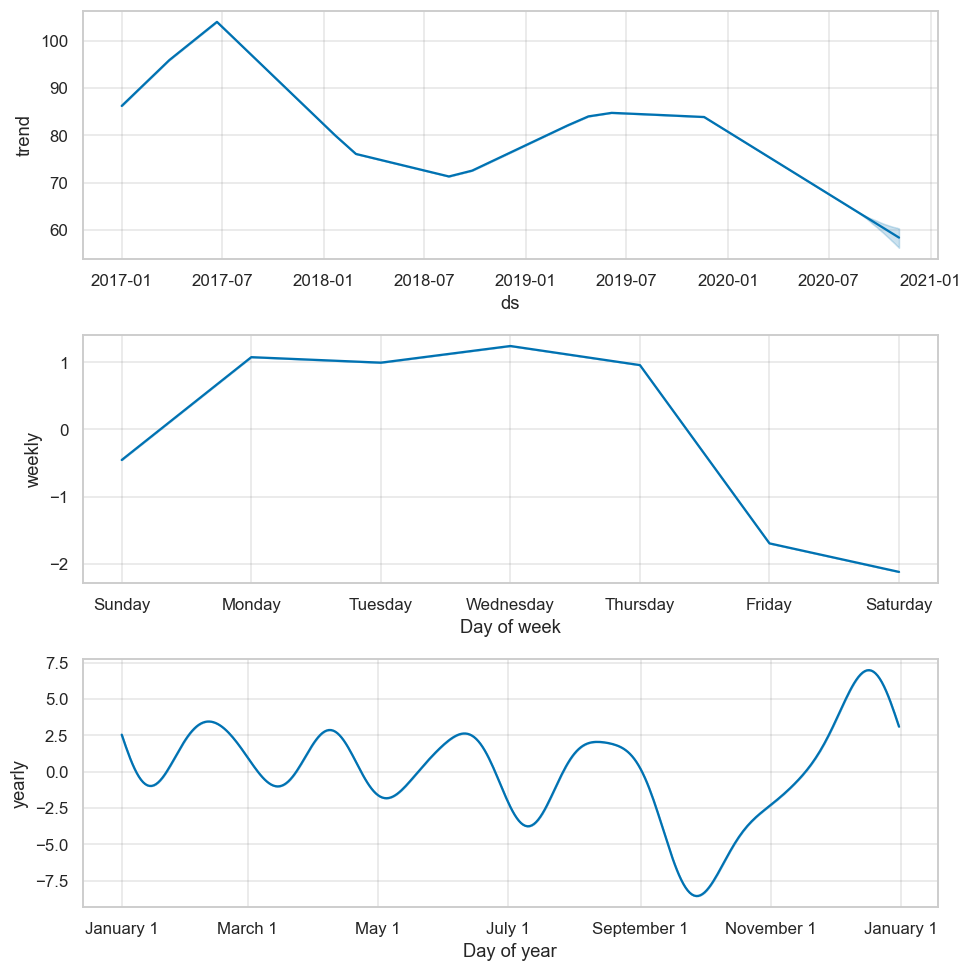

In [16]:
# les composantes : ce que le modele a quand meme appris
fig = modele.plot_components(prevision)
plt.tight_layout()
plt.show()


### Ce que le modèle capte quand même

La tendance descend depuis 2017, et sur ce point le modèle a raison. Le rythme hebdomadaire
retrouve tout seul le creux du vendredi et du samedi, il ne l'a pas inventé, il l'a lu dans les
données. Le rythme annuel montre le pic de décembre et le creux de fin d'été.

Le modèle a donc bien appris les régularités. Ce qu'il a raté, c'est le niveau : il sait quelle
forme a la semaine, pas à quelle hauteur elle se situe.

## 6. La prévision à six mois

Le modèle a été jugé. Je peux maintenant le réentraîner sur **toutes** les données, y compris les
90 jours de test, et produire la prévision que Camille attend.

Pourquoi réentraîner : les 90 derniers jours sont les plus récents, donc les plus informatifs. Les
mettre de côté servait à juger le modèle, pas à le priver d'information pour de bon.

In [17]:
# je reentraine sur tout, puis je prevois 6 mois
modele_final = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=MEILLEUR,   # le meme reglage que celui que j'ai teste
)
modele_final.fit(donnees)

futur_final = modele_final.make_future_dataframe(periods=JOURS_PREVISION)
prevision_finale = modele_final.predict(futur_final)

six_mois = prevision_finale.tail(JOURS_PREVISION)
print(f"prevision du {six_mois.ds.min():%d/%m/%Y} au {six_mois.ds.max():%d/%m/%Y}")
print(f"moyenne prevue     : {six_mois.yhat.mean():.1f} morceaux par jour")
print(f"le plus bas prevu  : {six_mois.yhat.min():.1f}")
print(f"le plus haut prevu : {six_mois.yhat.max():.1f}")
print(f"\nlargeur de l'intervalle a 1 mois : {(six_mois.yhat_upper - six_mois.yhat_lower).iloc[30]:.1f} morceaux")
print(f"largeur de l'intervalle a 6 mois : {(six_mois.yhat_upper - six_mois.yhat_lower).iloc[-1]:.1f} morceaux")

prevision du 06/11/2020 au 04/05/2021
moyenne prevue     : 81.9 morceaux par jour
le plus bas prevu  : 71.9
le plus haut prevu : 91.2

largeur de l'intervalle a 1 mois : 12.1 morceaux
largeur de l'intervalle a 6 mois : 29.3 morceaux


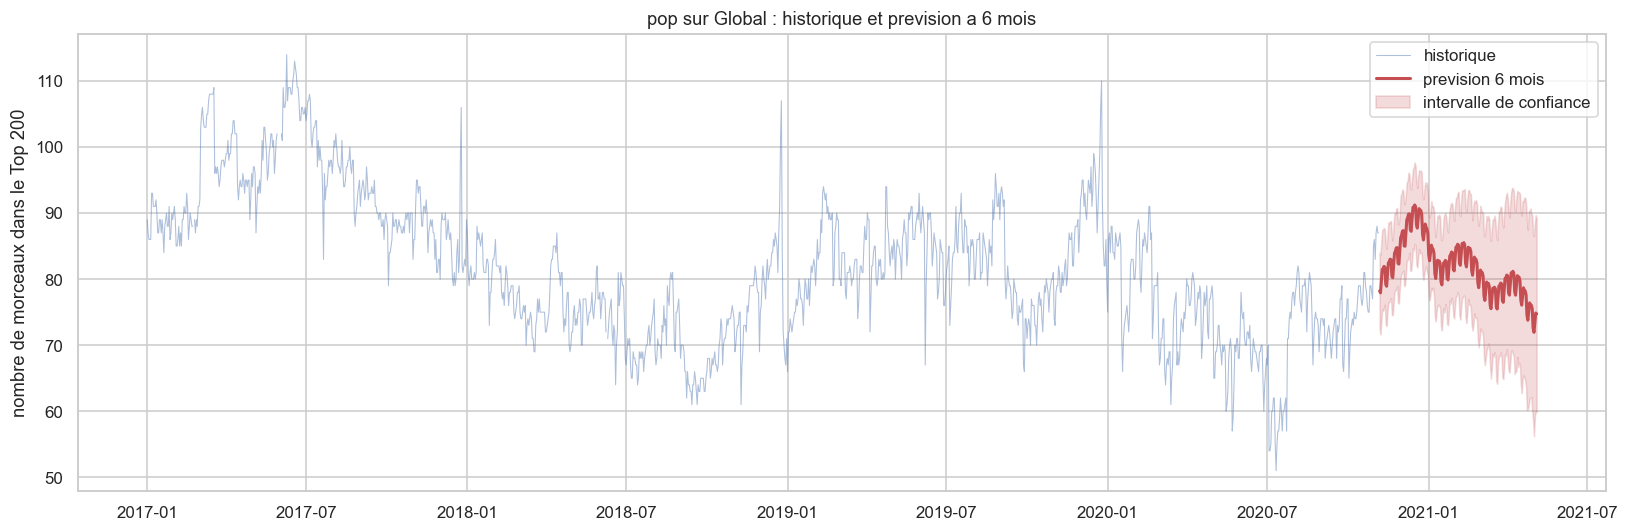

In [18]:
# la prevision livree, avec son intervalle
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(donnees.ds, donnees.y, lw=.7, alpha=.45, color="#4C72B0", label="historique")
ax.plot(six_mois.ds, six_mois.yhat, lw=2, color="#C44E52", label="prevision 6 mois")
ax.fill_between(six_mois.ds, six_mois.yhat_lower, six_mois.yhat_upper,
                color="#C44E52", alpha=.2, label="intervalle de confiance")
ax.set_title(f"{GENRE} sur {MARCHE} : historique et prevision a 6 mois")
ax.set_ylabel("nombre de morceaux dans le Top 200")
ax.legend()
plt.tight_layout()
plt.show()

### Comment lire cette prévision

Avant tout, un rappel : sur les 90 jours de test, ce modèle s'est trompé trois fois plus qu'une
simple moyenne des sept derniers jours, et toujours dans le même sens. Je livre donc cette
prévision en le disant, pas comme un résultat solide.

La forme est crédible. Le creux d'été, la remontée de décembre, la pente qui descend doucement :
ces motifs-là, le modèle les a bien appris. Le niveau exact, en revanche, est à prendre avec des
pincettes, puisque c'est précisément là qu'il s'est trompé.

L'intervalle s'élargit avec le temps, et c'est normal : plus on regarde loin, moins on sait. Le
chiffre du milieu n'est pas une promesse, c'est le centre d'une fourchette. Et sur le test, le réel
n'est presque jamais tombé dedans, ce qui veut dire que cette fourchette est trop étroite.

Tout repose sur une seule hypothèse : que ce qui s'est passé pendant quatre ans continue. Un
changement d'algorithme chez Spotify, un artiste qui explose, et elle ne vaut plus rien.

Ce que je conseillerais à Camille, c'est de se servir de la forme plutôt que du chiffre. Pour un
niveau à court terme, la moyenne des dernières semaines reste plus fiable, et je l'ai vérifié.

## 7. Bonus : le rythme des sorties

La présence dans les charts est une chose, le nombre de nouveautés produites en est une autre. Je
regarde le second fichier, qui donne les dates de sortie officielles.

In [19]:
# le rythme mensuel des sorties du genre
sorties = pd.read_csv("../data/release_dates_genre_2017_2020.csv",
                      usecols=["Release_date", "Genre_new"])
sorties["Release_date"] = pd.to_datetime(sorties.Release_date, errors="coerce")
sorties = sorties.dropna(subset=["Release_date"])

du_genre = sorties[sorties.Genre_new == GENRE]
par_mois_sorties = du_genre.set_index("Release_date").resample("MS").size()

print(f"{len(du_genre):,} sorties {GENRE} entre {par_mois_sorties.index.min():%m/%Y} "
      f"et {par_mois_sorties.index.max():%m/%Y}")
print(f"{len(par_mois_sorties)} mois de donnees")

14,463 sorties pop entre 01/2017 et 10/2020
46 mois de donnees


In [20]:
# meme methode que plus haut : je mets 6 mois de cote, j'entraine, je confronte
mensuel = par_mois_sorties.reset_index()
mensuel.columns = ["ds", "y"]

train_m = mensuel.iloc[:-6]
test_m = mensuel.iloc[-6:]

modele_m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
modele_m.fit(train_m)

futur_m = modele_m.make_future_dataframe(periods=6, freq="MS")
prev_m = modele_m.predict(futur_m)

prevu_m = prev_m.set_index("ds").loc[test_m.ds, "yhat"].values
reel_m = test_m.y.values

mae_m = np.mean(np.abs(reel_m - prevu_m))
mape_m = np.mean(np.abs((reel_m - prevu_m) / reel_m)) * 100
print(f"MAE  : {mae_m:.1f} sorties par mois")
print(f"MAPE : {mape_m:.1f} %")

MAE  : 47.9 sorties par mois
MAPE : 20.8 %


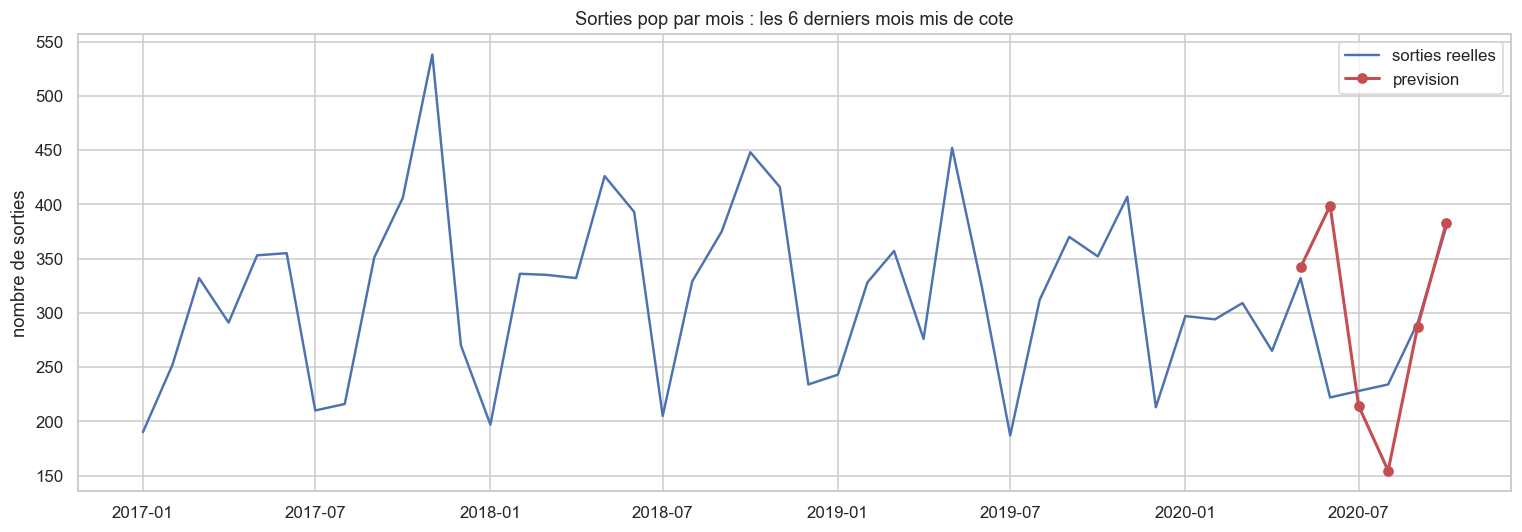

In [21]:
# sorties reelles et prevision sur les six derniers mois
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mensuel.ds, mensuel.y, lw=1.6, color="#4C72B0", label="sorties reelles")
ax.plot(test_m.ds, prevu_m, lw=2, color="#C44E52", marker="o", label="prevision")
ax.set_title(f"Sorties {GENRE} par mois : les 6 derniers mois mis de cote")
ax.set_ylabel("nombre de sorties")
ax.legend()
plt.tight_layout()
plt.show()

### Une prévision fragile, à cause des données

Le problème n'est pas le modèle, il est dans la donnée.

Ce fichier ne contient que les morceaux qui ont atteint le classement. Un titre sorti en novembre
2020 n'a pas encore eu le temps d'y entrer quand la collecte s'arrête, donc les derniers mois sont
mécaniquement sous-comptés.

La baisse qu'on voit à la fin de la courbe n'est pas une baisse de production, c'est un effet de
bord de la façon dont les données ont été rassemblées. Je garde ce bonus parce qu'il complète la
vision, mais je ne bâtirais aucune décision dessus.

## 8. Ce que je retiens pour Camille

Le nombre de morceaux Pop dans le Top 200 mondial est très stable d'un jour à l'autre, autour de
80 places sur 200. La Pop reste le premier genre du classement, mais elle recule depuis 2017.

Deux motifs reviennent régulièrement, et un seul est intuitif. Décembre est le point haut de
l'année. Le vendredi, en revanche, est un point bas pour la Pop : les nouveautés de tous les genres
entrent ce jour-là et lui prennent des places.

Le modèle a été jugé sur 90 jours qu'il n'avait jamais vus, et il a échoué. Une simple moyenne des
sept derniers jours fait mieux que lui, parce qu'il a pris un creux de fin d'été pour une tendance
durable. Je le livre quand même avec cette réserve écrite noir sur blanc : il reste utile pour la
forme de l'année et de la semaine, pas pour le niveau.

Concrètement, ça permet de planifier une sortie en décembre plutôt qu'en septembre, et d'éviter le
vendredi si l'objectif est d'entrer dans le Top 200 en Pop. Ces deux conseils reposent sur les
rythmes, que le modèle capte bien.

Ça ne permet pas de prévoir l'arrivée d'un artiste qui change la donne, ni un changement de règles
chez Spotify. La prévision prolonge le passé, elle ne l'invente pas.

Dernier point : le bonus sur les sorties souffre d'un défaut de collecte sur ses derniers mois. Je
l'ai signalé au moment où il apparaît, et je ne m'appuierais pas dessus.